In [ ]:
from langchain_google_genai import ChatGoogleGenerativeAI
from dotenv import load_dotenv
import os

True

In [ ]:
load_dotenv(override=True)

True

In [3]:
if os.environ.get("GOOGLE_API_KEY") is None:
    raise ValueError("GOOGLE_API_KEY is not set in the environment variables.")
else:
    llm = ChatGoogleGenerativeAI(
        model="gemini-3.5-flash-lite",
        api_key=os.environ.get("GOOGLE_API_KEY")
    )

In [4]:
llm.invoke("what is water?")

AIMessage(content=[{'type': 'text', 'text': 'At its most basic level, **water** is a chemical compound and a liquid substance that is essential for all known life. \n\nHere is a breakdown of what water is from different perspectives:\n\n### 1. The Chemical Perspective\n* **Chemical Formula:** $\\text{H}_2\\text{O}$\n* This means every single molecule of water is made up of **two hydrogen atoms** bonded to **one oxygen atom**.\n* **States of Matter:** Water is unique because it is the only natural substance on Earth that exists abundantly in three physical states:\n  * **Liquid** (water)\n  * **Solid** (ice)\n  * **Gas** (steam or water vapor)\n\n### 2. Physical Properties\n* **Appearance:** Pure water is transparent, odorless, and tasteless.\n* **The "Universal Solvent":** Water can dissolve more substances than any other liquid. This is why it can easily carry chemicals, minerals, and nutrients wherever it goes.\n* **Density:** Unlike most substances, water expands when it freezes, ma

## How to create a Graph
1. create Schema
2. create Nodes and connect them with Edges
3. Create a Graph
4. compile the graph

In [5]:
from typing import TypedDict, List

## create the schema for the state
class graph_schema(TypedDict):
    name : str
    message : str

In [6]:
## create the Node function that takes in the schema and returns the schema
def welcome(schema:graph_schema) -> graph_schema:

    curr_name = schema['name']
    curr_message = schema['message']

    response = llm.invoke(f"My name is {curr_name}. {curr_message}").content

    schema['message'] = f"Your message was {curr_message}. Here's my response:  {response}"

    return schema

In [7]:
from langgraph.graph import StateGraph, START, END

# create the graph
graph = StateGraph(graph_schema)

# Adding Nodes
graph.add_node("welcome", welcome)

# Adding Edges
graph.add_edge(START, "welcome")
graph.add_edge("welcome", END)

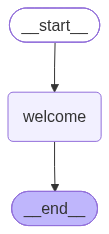

In [8]:
from IPython.display import Image, display

first_graph = graph.compile()

# You could see the errors with the below command
Image(first_graph.get_graph().draw_mermaid_png())

# You can use the below command to see the graph without errors
# print(first_graph.get_graph().draw_mermaid())

In [ ]:
# Now you can invoke the graph with the required input and returns teh state of the graph
first_graph.invoke({"name":"Srima","message":"How are you?"})

{'name': 'Srima',
 'message': 'Your message was How are you?. Here\'s my response:  [{\'type\': \'text\', \'text\': "Hello Srima! It\'s nice to meet you. I\'m doing well, thank you for asking. How are you doing today? Is there anything I can help you with?", \'extras\': {\'signature\': \'El4KXAERTTIPe2orF9Z4YLBY1ogS5SlaCgFVePnP7fQDNqBZoYU6D4CgR/VDLR881Uxxsz2O0j+0nBP3xqjwv7W0fns7xoLOOVHQHBgX9wYLY6MxH8PoaAXpMXcpSnDa\'}}]'}